## Deep Learning

### Chapter 16: Variational Autoencoders

A variational autoencoder (VAE) is a generative artificial neural network architecture that learns a smooth, probabilistic latent space to reconstruct existing data and generate entirely new realistic samples.

#### How a VAE Works?

* **Encoder**: The encoder takes an input (like an image or text) and maps it to a probability distribution (typically a Gaussian distribution) defined by a mean (μ) and variance/standard deviation (σ) instead of a single fixed point.

* **Latent Space Sampling**: The model picks a random latent vector z from this learned distribution.

* **Reparameterization Trick**: To allow gradient descent training, the model uses a deterministic trick (z = μ + ε ⋅ σ) where ε is random noise, making the random sampling step differentiable.

* **Decoder**: The decoder takes the sampled latent vector and reconstructs it back into the original data space, allowing the creation of novel data variations.

#### Loss Function

* **Reconstruction Loss**: Measures how closely the decoder's output matches the original input data.

* **KL Divergence**: Regularizes the latent distribution by measuring its difference from a standard normal distribution, ensuring a smooth, continuous, and overlapping latent space.

#### Common Applications

* Generating new images, audio, or text variations

* Anomaly and outlier detection

* Dimensionality reduction and denoising

* Drug molecule generation

### 1. Building the Encoder

We first define the dimensionality of the latent space.

In [1]:
from tensorflow import keras
from tensorflow.keras import layers

latent_dim = 2

encoder_inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
encoder = keras.Model(encoder_inputs, [z_mean, z_log_var], name="encoder")

encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 14, 14,    │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 7, 7, 64)  │     18,496 │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │     50,192 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │         34 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │         34 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,076 (269.83 KB)

 Trainable params: 69,076 (269.83 KB)

 Non-trainable params: 0 (0.00 B)

### 2. Building the Sampling Layer

We create a custom Keras layer to take the mean and variance produced by the encoder and randomly sample a point from the latent distribution.

In [2]:
import tensorflow as tf

class Sampler(layers.Layer):
    def call(self, z_mean, z_log_var):
        batch_size = tf.shape(z_mean)[0]
        z_size = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch_size, z_size))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

### 3. Building the Decoder

The decoder performs the opposite operation of the encoder. It receives a point from the two-dimensional latent space and attempts to turn it back into a **28 × 28 grayscale image**.

In [3]:
latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)
decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")

decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

### 4. Building the VAE Model

We now have the three fundamental pieces: ***Encoder → Sampler → Decoder***

However, a VAE needs a special training process because its loss contains two different objectives: Reconstruction loss and KL divergence loss

Because of this, we will create a custom Keras model and define its training step ourselves.

In [4]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.sampler = Sampler()
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var = self.encoder(data)
            z = self.sampler(z_mean, z_log_var)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(tf.reduce_sum(keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2)))
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            total_loss = reconstruction_loss + tf.reduce_mean(kl_loss)

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {"total_loss": self.total_loss_tracker.result(), "reconstruction_loss": self.reconstruction_loss_tracker.result(), "kl_loss": self.kl_loss_tracker.result()}

### 5. Training the VAE

Now we can prepare the MNIST dataset. MNIST already provides separate training and testing sets. For this particular visualization example, we concatenate them so that the VAE can learn from the complete collection of available digits.

In [5]:
import numpy as np

(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()
mnist_digits = np.concatenate([x_train, x_test], axis=0)
mnist_digits = np.expand_dims(mnist_digits, -1).astype("float32") / 255

We can now create and compile the VAE.

In [6]:
vae_model = VAE(encoder, decoder)
vae_model.compile(optimizer=keras.optimizers.Adam(), run_eagerly=True)

vae_model.summary()

Model: "vae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Functional)            │ ((None, 2), (None, 2)) │        69,076 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 28, 28, 1)      │        65,089 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sampler (Sampler)               │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,165 (524.08 KB)

 Trainable params: 134,165 (524.08 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Train the VAE model
vae_model.fit(mnist_digits, epochs=30, batch_size=128)

Epoch 1/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 110s 201ms/step - kl_loss: 2.9404 - reconstruction_loss: 204.0342 - total_loss: 206.9750
Epoch 2/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 121s 221ms/step - kl_loss: 4.1009 - reconstruction_loss: 167.3718 - total_loss: 171.4727
Epoch 3/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 100s 182ms/step - kl_loss: 3.7520 - reconstruction_loss: 160.1241 - total_loss: 163.8761
Epoch 4/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 93s 170ms/step - kl_loss: 3.8093 - reconstruction_loss: 155.4865 - total_loss: 159.2957
Epoch 5/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 112s 205ms/step - kl_loss: 3.8666 - reconstruction_loss: 152.6966 - total_loss: 156.5630
Epoch 6/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 104s 189ms/step - kl_loss: 3.8938 - reconstruction_loss: 150.6867 - total_loss: 154.5806
Epoch 7/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 98s 178ms/step - kl_loss: 3.9199 - reconstruction_loss: 149.3376 - total_loss: 153.2574
Epoch 8/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 98s 179ms/step - kl_loss: 3.9202 - reconstruction_loss: 148

### 6. Exploring the 2D Latent Space

One of the most interesting advantages of using a two-dimensional latent space is that we can visualize it. Instead of choosing one random latent point, we can create a grid of points covering a region of the latent space.

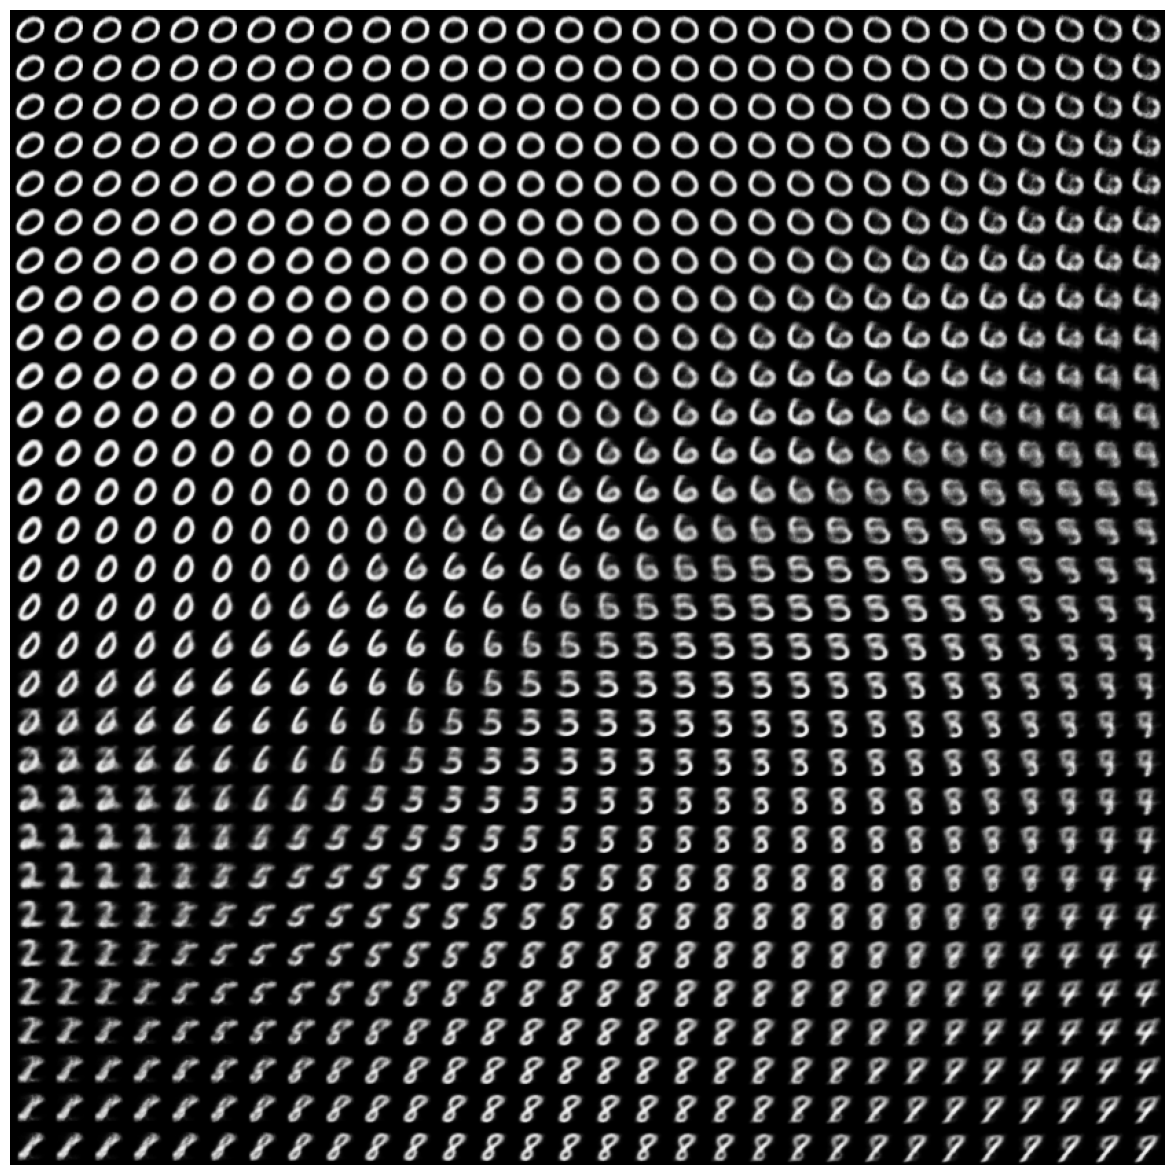

In [8]:
import matplotlib.pyplot as plt

n = 30
digit_size = 28
figure = np.zeros((digit_size * n, digit_size * n))
grid_x = np.linspace(-1, 1, n)
grid_y = np.linspace(-1, 1, n)[::-1]

for i, yi in enumerate(grid_y):
    for j, xi in enumerate(grid_x):
        z_sample = np.array([[xi, yi]])
        x_decoded = vae_model.decoder.predict(z_sample, verbose=0)
        digit = x_decoded[0].reshape(digit_size, digit_size)
        figure[i * digit_size : (i + 1) * digit_size, j * digit_size : (j + 1) * digit_size] = digit

plt.figure(figsize=(15, 15))
start_range = digit_size // 2
end_range = n * digit_size + start_range
pixel_range = np.arange(start_range, end_range, digit_size)
sample_range_x = np.round(grid_x, 1)
sample_range_y = np.round(grid_y, 1)
plt.xticks(pixel_range, sample_range_x)
plt.yticks(pixel_range, sample_range_y)
plt.xlabel("z[0]")
plt.ylabel("z[1]")
plt.axis("off")
plt.imshow(figure, cmap="Greys_r")
plt.show()